In [182]:
# from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv
# from typing import TypedDict
# from IPython.display import Image


# load_dotenv()

In [183]:
# class Speed(TypedDict):
#     distance: int
#     time: int
#     output: float

In [184]:
# def calculate_speed(state:Speed) -> Speed:

#     output=state['distance']/state['time']
#     state['output']=output

#     return {"output":state['output']}

In [185]:
# graph=StateGraph(Speed)
# graph.add_node("calculate_speed",calculate_speed)

# graph.add_edge(START,"calculate_speed")
# graph.add_edge("calculate_speed", END)

# workflow=graph.compile()

In [186]:
# Image(workflow.get_graph().draw_mermaid_png())

In [187]:
# print(workflow.invoke({"distance":43,"time":50}))

In [188]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
from IPython.display import Image, Markdown
from langchain.prompts import PromptTemplate
from pydantic import BaseModel, Field


load_dotenv()

True

In [189]:
gpt_llm = ChatOpenAI(model="gpt-4o-mini")

In [190]:
class TopicClassifier(BaseModel):
    topic_background: Literal["Physics","Technology","Chemistry","Others"] =  Field(description="The field will define the person's background")

In [191]:
structured_output=gpt_llm.with_structured_output(TopicClassifier)

In [192]:
class Article(TypedDict):
    topic: str
    output: str
    named_entity: str
    summary: str
    topic_classifier: str
    

In [193]:
def topic_classifier(state:Article)->Article:
    prompt=f"For the given topic {state['topic']}, please classify the topic in Physics , Technology, Chemistry"

    structured_output_llm=structured_output.invoke(prompt)

    return {"topic_classifier" : structured_output_llm.topic_background}

In [194]:
def generate_article(state:Article)-> Article:
    prompt = PromptTemplate.from_template("You are an AI assistant that helps in display information about the personalities: {topic}. \n\n Try fetching as many details as possible about full name, birth place, organization, age, nationality, but keep the whole response in 3 paragraph.")

    chain = prompt | gpt_llm

    output=chain.invoke({"topic":state['topic']})

    return {"output": output.content}

In [195]:
def generate_named_entity(state:Article)-> Article:
    prompt = f"""You are an AI assistant that helps in finding the named entity recognition [NER] for the personality {state['topic']} from below article \n\n 
                                          {state['output']}
                                          """
    named_entity=gpt_llm.invoke(prompt)

    return {"named_entity": named_entity.content}

In [196]:
def generate_summary(state:Article)-> Article:
    prompt = f"""Please help in generating the summary for the article {state["output"]} in 2 paragraphs."""

    summary=gpt_llm.invoke(prompt)

    return {"summary": summary.content}

In [197]:
graph=StateGraph(Article)
graph.add_node("topic_classifier",topic_classifier)
graph.add_node("generate_article",generate_article)
graph.add_node("generate_named_entity",generate_named_entity)
graph.add_node("generate_summary",generate_summary)

graph.add_edge(START,"generate_article")
graph.add_edge("generate_article", "generate_named_entity")
graph.add_edge("generate_article", "topic_classifier")
graph.add_edge("generate_article", "generate_summary")


workflow=graph.compile()

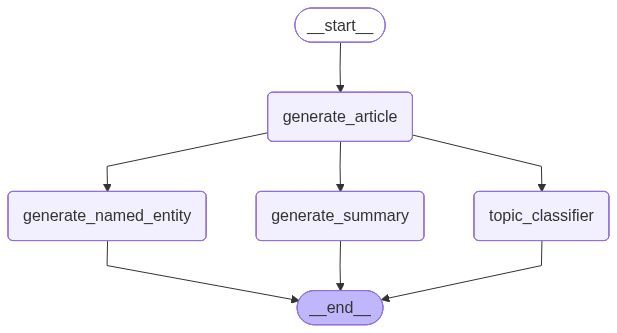

In [198]:
Image(workflow.get_graph().draw_mermaid_png())

In [205]:
result=workflow.invoke({"topic":"Sundar Pichai"})

In [206]:
print(result)

{'topic': 'Sundar Pichai', 'output': 'Sundar Pichai, whose full name is Pichai Sundararajan, is a prominent Indian-American technology executive known for his role as the CEO of Alphabet Inc. and its subsidiary Google LLC. He was born on June 10, 1972, in Madurai, Tamil Nadu, India. Pichai earned his degree in Metallurgical Engineering from the Indian Institute of Technology (IIT) Kharagpur, and later pursued an M.S. in Material Sciences from Stanford University, followed by an MBA from the Wharton School of the University of Pennsylvania.\n\nPichai joined Google in 2004, where he initially worked on the Google Toolbar and later led the Chrome browser project, which became one of the most popular web browsers worldwide. His innovative vision for technology and strong leadership skills facilitated his rise within the company, and in August 2015, he was appointed CEO of Google. This role expanded in December 2019 when he became the CEO of Alphabet Inc., Google’s parent company, overseein

In [207]:
Markdown(result["output"])

Sundar Pichai, whose full name is Pichai Sundararajan, is a prominent Indian-American technology executive known for his role as the CEO of Alphabet Inc. and its subsidiary Google LLC. He was born on June 10, 1972, in Madurai, Tamil Nadu, India. Pichai earned his degree in Metallurgical Engineering from the Indian Institute of Technology (IIT) Kharagpur, and later pursued an M.S. in Material Sciences from Stanford University, followed by an MBA from the Wharton School of the University of Pennsylvania.

Pichai joined Google in 2004, where he initially worked on the Google Toolbar and later led the Chrome browser project, which became one of the most popular web browsers worldwide. His innovative vision for technology and strong leadership skills facilitated his rise within the company, and in August 2015, he was appointed CEO of Google. This role expanded in December 2019 when he became the CEO of Alphabet Inc., Google’s parent company, overseeing a broad array of technology ventures that go beyond search and advertising.

As of October 2023, Sundar Pichai is 51 years old and holds American nationality, having moved to the United States for his higher education and career. His leadership has not only influenced the direction of Google but has also shaped significant advancements in AI, cloud computing, and consumer technology, making him one of the most influential figures in the global tech industry.

In [208]:
Markdown(result["named_entity"])

Here are the named entities related to Sundar Pichai from the provided article:

1. **Person:**
   - Sundar Pichai
   - Pichai Sundararajan

2. **Organizations:**
   - Alphabet Inc.
   - Google LLC
   - Indian Institute of Technology (IIT) Kharagpur
   - Stanford University
   - Wharton School of the University of Pennsylvania

3. **Location:**
   - Madurai
   - Tamil Nadu
   - India
   - United States

4. **Date:**
   - June 10, 1972
   - August 2015
   - December 2019
   - October 2023

5. **Field/Concept:**
   - Metallurgical Engineering
   - Material Sciences
   - MBA
   - Chrome browser
   - AI
   - Cloud computing
   - Consumer technology

This list includes the key entities and concepts associated with Sundar Pichai as mentioned in the article.

In [209]:
Markdown(result["summary"])

Sundar Pichai, born Pichai Sundararajan on June 10, 1972, in Madurai, Tamil Nadu, India, is a distinguished Indian-American technology executive recognized for his influential role as the CEO of Alphabet Inc. and its subsidiary, Google LLC. After earning his degree in Metallurgical Engineering from the Indian Institute of Technology (IIT) Kharagpur, Pichai pursued higher education in the United States, obtaining an M.S. in Material Sciences from Stanford University and an MBA from the Wharton School at the University of Pennsylvania. He joined Google in 2004, where he initially contributed to the development of the Google Toolbar and later spearheaded the Chrome browser project, which became immensely popular worldwide.

Pichai’s innovative vision and strong leadership skills led to his appointment as CEO of Google in August 2015, a role that expanded in December 2019 when he assumed the position of CEO of Alphabet Inc. At the age of 51, Pichai has become a significant figure in the technology industry, overseeing a diverse range of projects that extend beyond search and advertising. His leadership has driven advancements in artificial intelligence, cloud computing, and consumer technology, solidifying his influence in shaping the future of technology on a global scale.

In [210]:
Markdown(result["topic_classifier"])

Technology